In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

print ("Setup completed.")

Setup completed.


In [3]:
ticker = "AAPL"
start_date = "2015-01-01"
end_date = "2024-12-31"

df = yf.download(ticker, start=start_date, end=end_date)

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.192608,24.659510,23.754472,24.648445,212818400
2015-01-05,23.511057,24.042131,23.325182,23.962469,257142000
2015-01-06,23.513275,23.772173,23.152587,23.575233,263188400
2015-01-07,23.842981,23.942557,23.610636,23.721276,160423600
2015-01-08,24.759077,24.816610,24.053192,24.170472,237458000


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
DatetimeIndex: 2515 entries, 2015-01-02 to 2024-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   2515 non-null   float64
 1   (High, AAPL)    2515 non-null   float64
 2   (Low, AAPL)     2515 non-null   float64
 3   (Open, AAPL)    2515 non-null   float64
 4   (Volume, AAPL)  2515 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.9 KB
None


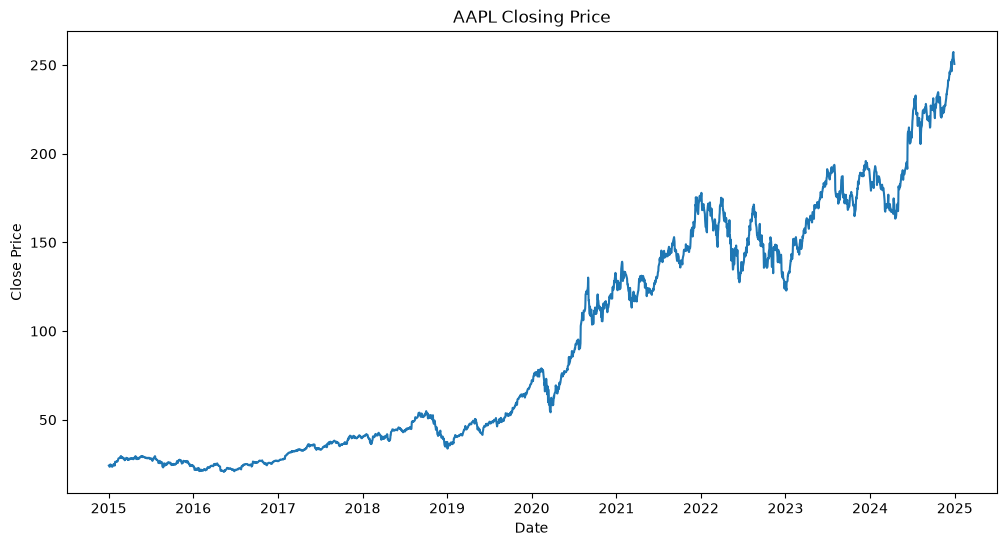

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(df["Close"])
plt.title("AAPL Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

In [6]:
close_data = df[["Close"]].copy()

print(close_data.shape)
close_data.head()

(2515, 1)


Price,Close
Ticker,AAPL
Date,
2015-01-02,24.192608
2015-01-05,23.511057
2015-01-06,23.513275
2015-01-07,23.842981
2015-01-08,24.759077


In [7]:
print(close_data.isnull().sum())

close_data = close_data.dropna()

print("Temizlenmiş veri boyutu:", close_data.shape)

Price  Ticker
Close  AAPL      0
dtype: int64
Temizlenmiş veri boyutu: (2515, 1)


In [8]:
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(close_data)

print(scaled_data[:5])
print("Scaled data shape:", scaled_data.shape)

[[0.015315  ]
 [0.01243695]
 [0.01244632]
 [0.0138386 ]
 [0.01770709]]
Scaled data shape: (2515, 1)


In [9]:
def create_sequences(data, sequence_length=60):
    X = []
    y = []

    for i in range(sequence_length, len(data)):
        X.append(data[i - sequence_length:i])
        y.append(data[i])

    return np.array(X), np.array(y)

In [10]:
sequence_length = 60

X, y = create_sequences(scaled_data, sequence_length)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2455, 60, 1)
y shape: (2455, 1)


In [11]:
train_size = int(len(X) * 0.80)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1964, 60, 1)
X_test: (491, 60, 1)
y_train: (1964, 1)
y_test: (491, 1)


In [12]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

print("X train tensor:", X_train_tensor.shape)
print("y train tensor:", y_train_tensor.shape)

X train tensor: torch.Size([1964, 60, 1])
y train tensor: torch.Size([1964, 1])


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Kullanılan cihaz:", device)

Kullanılan cihaz: cpu


In [14]:
X_train_tensor = X_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)

y_train_tensor = y_train_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

In [15]:
class LSTMModel(nn.Module):
    def __init__(
        self,
        input_size=1,
        hidden_size=64,
        num_layers=2,
        output_size=1,
        dropout=0.2
    ):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        lstm_output, _ = self.lstm(x)

        last_output = lstm_output[:, -1, :]

        prediction = self.fc(last_output)

        return prediction

In [16]:
lstm_model = LSTMModel().to(device)

print(lstm_model)

LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [17]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=0.001
)

In [18]:
from torch.utils.data import TensorDataset, DataLoader

In [19]:
batch_size = 32

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Batch sayısı:", len(train_loader))

Batch sayısı: 62


In [20]:
epochs = 50
lstm_losses = []

for epoch in range(epochs):
    lstm_model.train()

    total_loss = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        predictions = lstm_model(batch_X)

        loss = criterion(predictions, batch_y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)
    lstm_losses.append(average_loss)

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch [{epoch + 1}/{epochs}], "
            f"Loss: {average_loss:.6f}"
        )

Epoch [5/50], Loss: 0.024691
Epoch [10/50], Loss: 0.001029
Epoch [15/50], Loss: 0.002377
Epoch [20/50], Loss: 0.000972
Epoch [25/50], Loss: 0.000627
Epoch [30/50], Loss: 0.000675
Epoch [35/50], Loss: 0.000685
Epoch [40/50], Loss: 0.000625
Epoch [45/50], Loss: 0.000890
Epoch [50/50], Loss: 0.000826


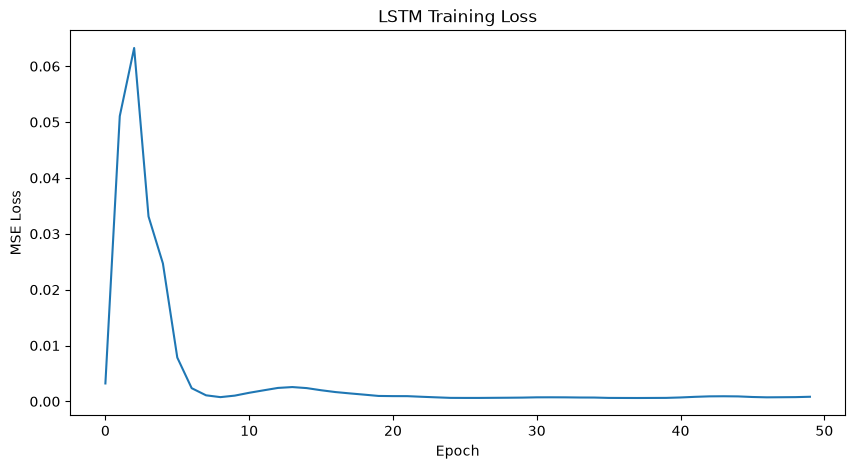

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(lstm_losses)
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

In [22]:
lstm_model.eval()

with torch.no_grad():
    lstm_predictions_scaled = lstm_model(
        X_test_tensor
    ).cpu().numpy()

In [23]:
y_test_scaled = y_test_tensor.cpu().numpy()

In [24]:
lstm_predictions = scaler.inverse_transform(
    lstm_predictions_scaled
)

actual_prices = scaler.inverse_transform(
    y_test_scaled
)

print("Tahminler:")
print(lstm_predictions[:5])

print("Gerçek fiyatlar:")
print(actual_prices[:5])

Tahminler:
[[143.623  ]
 [144.11209]
 [144.44724]
 [145.01585]
 [145.9516 ]]
Gerçek fiyatlar:
[[132.9535 ]
 [133.01251]
 [135.56909]
 [138.75502]
 [140.15132]]


In [25]:
from sklearn.metrics import mean_absolute_error

In [26]:
lstm_mse = mean_squared_error(
    actual_prices,
    lstm_predictions
)

lstm_rmse = np.sqrt(lstm_mse)

lstm_mae = mean_absolute_error(
    actual_prices,
    lstm_predictions
)

print(f"LSTM MSE: {lstm_mse:.4f}")
print(f"LSTM RMSE: {lstm_rmse:.4f}")
print(f"LSTM MAE: {lstm_mae:.4f}")

LSTM MSE: 503.9462
LSTM RMSE: 22.4487
LSTM MAE: 17.0039


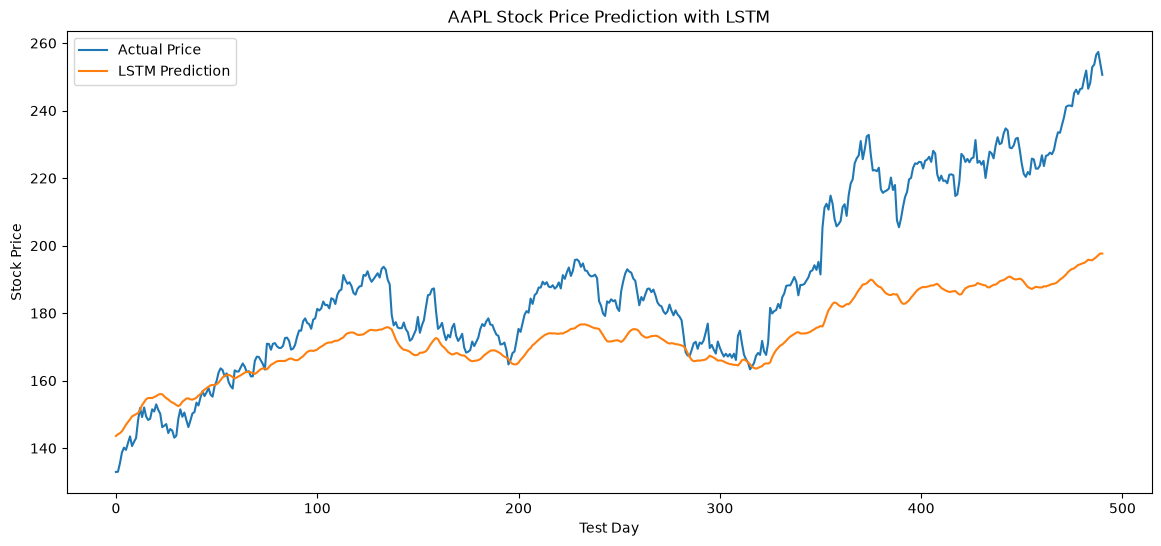

In [27]:
plt.figure(figsize=(14, 6))

plt.plot(
    actual_prices,
    label="Actual Price"
)

plt.plot(
    lstm_predictions,
    label="LSTM Prediction"
)

plt.title("AAPL Stock Price Prediction with LSTM")
plt.xlabel("Test Day")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

In [28]:
## GRU MODEL

In [29]:
class GRUModel(nn.Module):
    def __init__(
        self,
        input_size=1,
        hidden_size=64,
        num_layers=2,
        output_size=1,
        dropout=0.2
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        gru_output, _ = self.gru(x)

        last_output = gru_output[:, -1, :]

        prediction = self.fc(last_output)

        return prediction

In [30]:
gru_model = GRUModel().to(device)

print(gru_model)

GRUModel(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [31]:
gru_optimizer = torch.optim.Adam(
    gru_model.parameters(),
    lr=0.001
)

In [32]:
gru_epochs = 50
gru_losses = []

for epoch in range(gru_epochs):
    gru_model.train()

    total_loss = 0

    for batch_X, batch_y in train_loader:
        gru_optimizer.zero_grad()

        predictions = gru_model(batch_X)

        loss = criterion(predictions, batch_y)

        loss.backward()

        gru_optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)
    gru_losses.append(average_loss)

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch [{epoch + 1}/{gru_epochs}], "
            f"Loss: {average_loss:.6f}"
        )

Epoch [5/50], Loss: 0.037244
Epoch [10/50], Loss: 0.000590
Epoch [15/50], Loss: 0.000659
Epoch [20/50], Loss: 0.002511
Epoch [25/50], Loss: 0.000778
Epoch [30/50], Loss: 0.000600
Epoch [35/50], Loss: 0.000685
Epoch [40/50], Loss: 0.000751
Epoch [45/50], Loss: 0.000663
Epoch [50/50], Loss: 0.000640


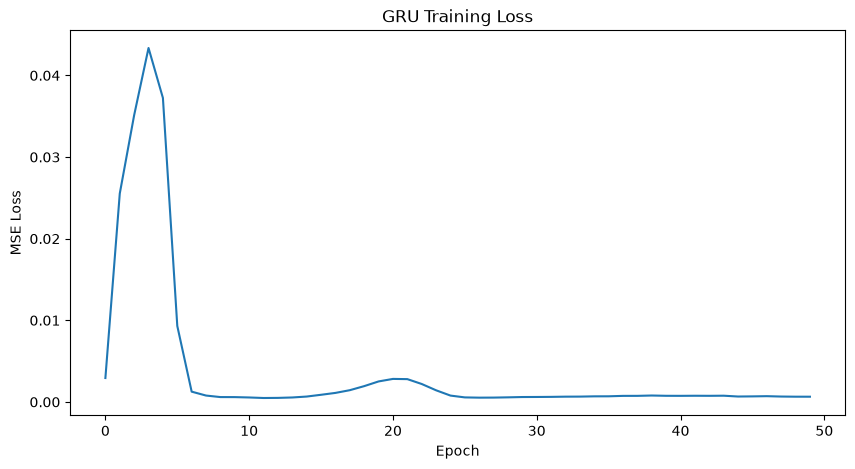

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(gru_losses)
plt.title("GRU Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

In [34]:
gru_model.eval()

with torch.no_grad():
    gru_predictions_scaled = gru_model(
        X_test_tensor
    ).cpu().numpy()

In [35]:
gru_predictions = scaler.inverse_transform(
    gru_predictions_scaled
)

print(gru_predictions[:5])

[[143.15813]
 [143.53264]
 [143.74449]
 [144.48804]
 [145.80423]]


In [36]:
gru_predictions = scaler.inverse_transform(
    gru_predictions_scaled
)

print(gru_predictions[:5])

[[143.15813]
 [143.53264]
 [143.74449]
 [144.48804]
 [145.80423]]


In [37]:
gru_mse = mean_squared_error(
    actual_prices,
    gru_predictions
)

gru_rmse = np.sqrt(gru_mse)

gru_mae = mean_absolute_error(
    actual_prices,
    gru_predictions
)

print(f"GRU MSE: {gru_mse:.4f}")
print(f"GRU RMSE: {gru_rmse:.4f}")
print(f"GRU MAE: {gru_mae:.4f}")

GRU MSE: 323.7950
GRU RMSE: 17.9943
GRU MAE: 13.3108


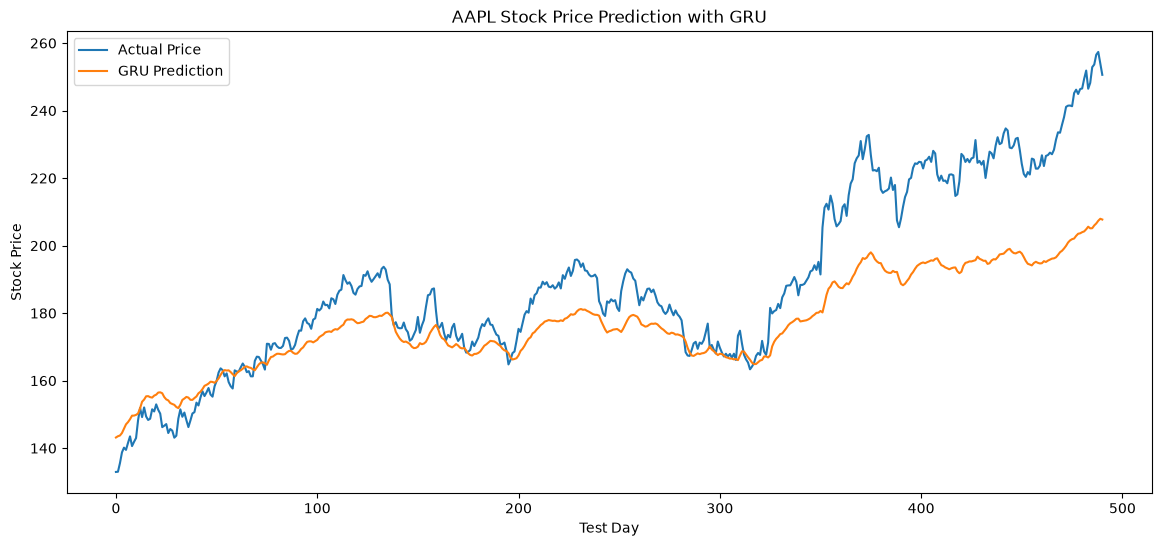

In [38]:
plt.figure(figsize=(14, 6))

plt.plot(
    actual_prices,
    label="Actual Price"
)

plt.plot(
    gru_predictions,
    label="GRU Prediction"
)

plt.title("AAPL Stock Price Prediction with GRU")
plt.xlabel("Test Day")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

In [39]:
results = pd.DataFrame({
    "Model": ["LSTM", "GRU"],
    "MSE": [lstm_mse, gru_mse],
    "RMSE": [lstm_rmse, gru_rmse],
    "MAE": [lstm_mae, gru_mae]
})

results

,Model,MSE,RMSE,MAE
0,LSTM,503.946198,22.448746,17.003918
1,GRU,323.794952,17.994303,13.310802


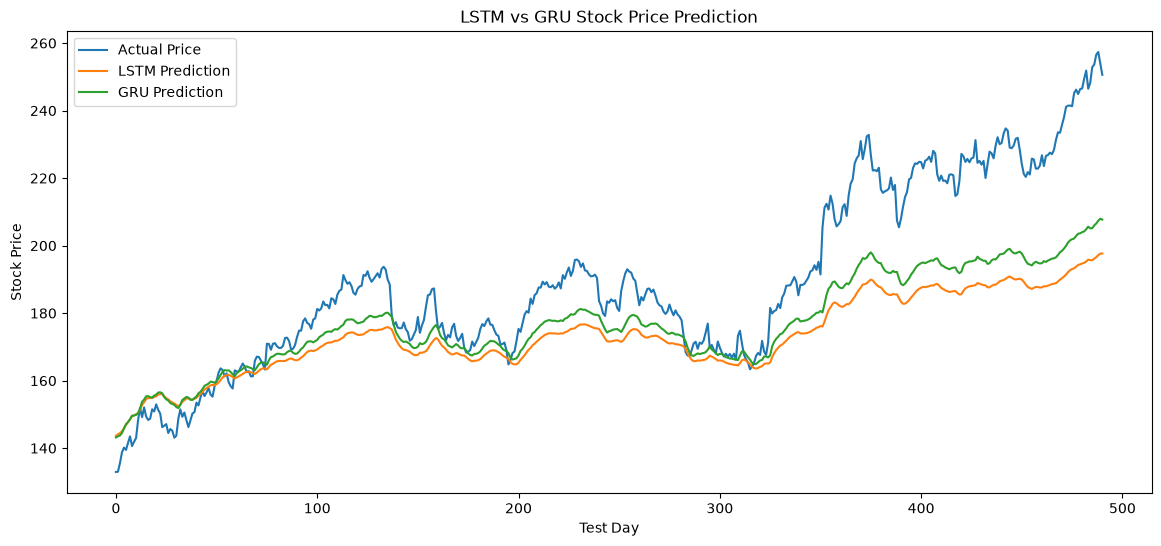

In [40]:
plt.figure(figsize=(14, 6))

plt.plot(
    actual_prices,
    label="Actual Price"
)

plt.plot(
    lstm_predictions,
    label="LSTM Prediction"
)

plt.plot(
    gru_predictions,
    label="GRU Prediction"
)

plt.title("LSTM vs GRU Stock Price Prediction")
plt.xlabel("Test Day")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

In [41]:
best_model = results.loc[results["RMSE"].idxmin(), "Model"]

print("Best model based on RMSE:", best_model)

Best model based on RMSE: GRU


In [42]:
## Compare LSTM and GRU Models

In [43]:
results = pd.DataFrame({
    "Model": ["LSTM", "GRU"],
    "MSE": [lstm_mse, gru_mse],
    "RMSE": [lstm_rmse, gru_rmse],
    "MAE": [lstm_mae, gru_mae]
})

results

,Model,MSE,RMSE,MAE
0,LSTM,503.946198,22.448746,17.003918
1,GRU,323.794952,17.994303,13.310802


In [44]:
best_model = results.loc[results["RMSE"].idxmin(), "Model"]

print("Best model based on RMSE:", best_model)

Best model based on RMSE: GRU


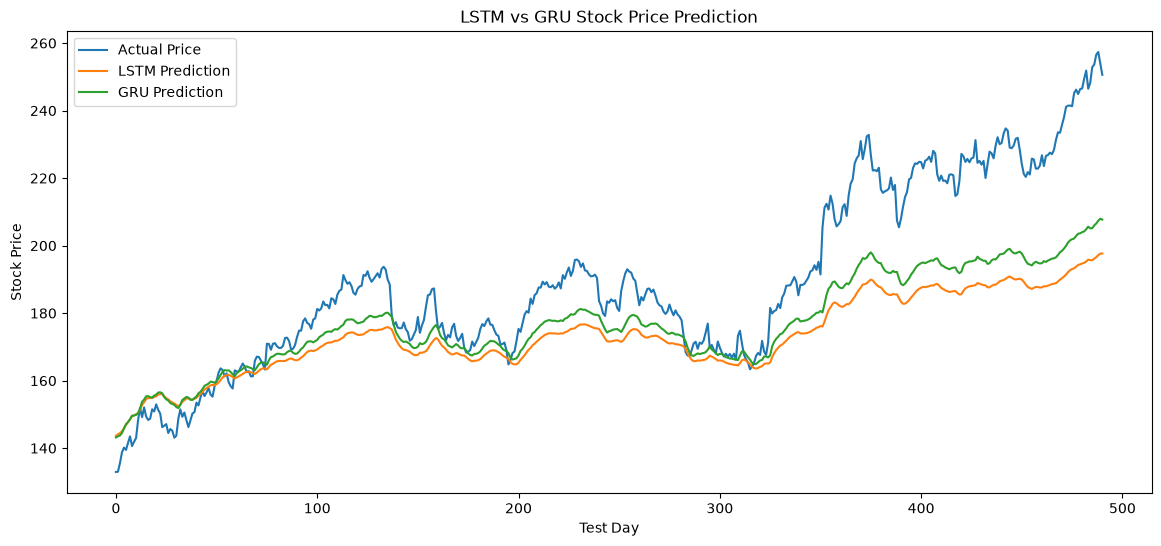

In [45]:
plt.figure(figsize=(14, 6))

plt.plot(actual_prices, label="Actual Price")
plt.plot(lstm_predictions, label="LSTM Prediction")
plt.plot(gru_predictions, label="GRU Prediction")

plt.title("LSTM vs GRU Stock Price Prediction")
plt.xlabel("Test Day")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

In [46]:
import os

os.makedirs("../models", exist_ok=True)

torch.save(
    lstm_model.state_dict(),
    "../models/lstm_model.pth"
)

torch.save(
    gru_model.state_dict(),
    "../models/gru_model.pth"
)

print("Models saved successfully.")

Models saved successfully.


In [47]:
results.to_csv(
    "../data/model_comparison.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


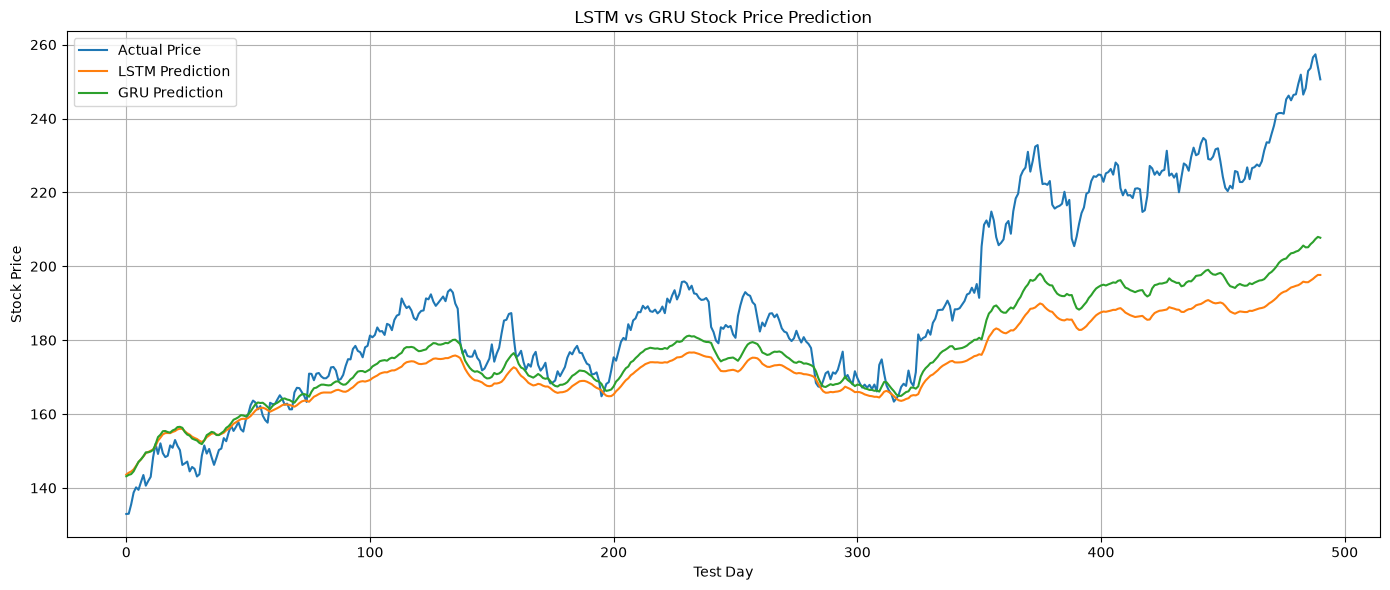

Graph saved successfully!


In [50]:
import os
import matplotlib.pyplot as plt

os.makedirs("../images", exist_ok=True)

plt.figure(figsize=(14, 6))

plt.plot(actual_prices, label="Actual Price")
plt.plot(lstm_predictions, label="LSTM Prediction")
plt.plot(gru_predictions, label="GRU Prediction")

plt.title("LSTM vs GRU Stock Price Prediction")
plt.xlabel("Test Day")
plt.ylabel("Stock Price")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "../images/lstm_vs_gru_prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Graph saved successfully!")